# **Data Manipulation**

**importing pandas and numpy**

In [1]:
import pandas as pd
import numpy as np

**mouting drive for the data**

In [2]:
from google.colab import drive
drive.mount("/content/Drive")

Mounted at /content/Drive


In [12]:
df = pd.read_csv("/content/Drive/MyDrive/dsml/new_titanic.csv")

**printing all of the column names**

In [13]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

**type conversion of astype**

In [14]:
df.Pclass.astype("int8")

,Pclass
0,3
1,1
2,3
3,1
4,3
...,...
886,2
887,1
888,3
889,1


In [15]:
df_change = df.astype(
    {
        "Survived" : bool,
        "Fare" : int
    }
)

In [16]:
df_change.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S
1,2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71,C85,C
2,3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7,NaN,S
3,4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53,C123,S
4,5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8,NaN,S


In [17]:
df_change.index

RangeIndex(start=0, stop=891, step=1)

In [19]:
df_change.index = df_change.PassengerId.astype(str) + "_skillshikshya"

In [20]:
df_change.index

Index(['1_skillshikshya', '2_skillshikshya', '3_skillshikshya',
       '4_skillshikshya', '5_skillshikshya', '6_skillshikshya',
       '7_skillshikshya', '8_skillshikshya', '9_skillshikshya',
       '10_skillshikshya',
       ...
       '882_skillshikshya', '883_skillshikshya', '884_skillshikshya',
       '885_skillshikshya', '886_skillshikshya', '887_skillshikshya',
       '888_skillshikshya', '889_skillshikshya', '890_skillshikshya',
       '891_skillshikshya'],
      dtype='object', name='PassengerId', length=891)

In [24]:
import random
n = random.randint(1,100)
# i was boored so that's why i did but idk why i did this
df_change.loc[f"{n}_skillshikshya"]

,49_skillshikshya
PassengerId,49
Survived,False
Pclass,3
Name,"Samaan, Mr. Youssef"
Sex,male
Age,NaN
SibSp,2
Parch,0
Ticket,2662
Fare,21


# **Indexing**

- **set index**

In [25]:
df_change = df_change.set_index("PassengerId")
df_change.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S
2,True,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71,C85,C
3,True,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7,NaN,S
4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53,C123,S
5,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8,NaN,S


- **reset index**

In [26]:
df_change.drop([2,3,8,66,100],axis = 0,inplace = True)

In [29]:
df_change.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S
4,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53,C123,S


In [30]:
df_change.reset_index(drop = True,inplace = True)

In [31]:
df_change.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7,NaN,S
1,True,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53,C123,S
2,False,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8,NaN,S
3,False,3,"Moran, Mr. James",male,NaN,0,0,330877,8,NaN,Q
4,False,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51,E46,S


# **Handling Outliers**

In [33]:
df = pd.read_csv("/content/Drive/MyDrive/dsml/titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: title={'center': 'Box plot of Age of passenger in Titanic'}, ylabel='Age of passenger'>

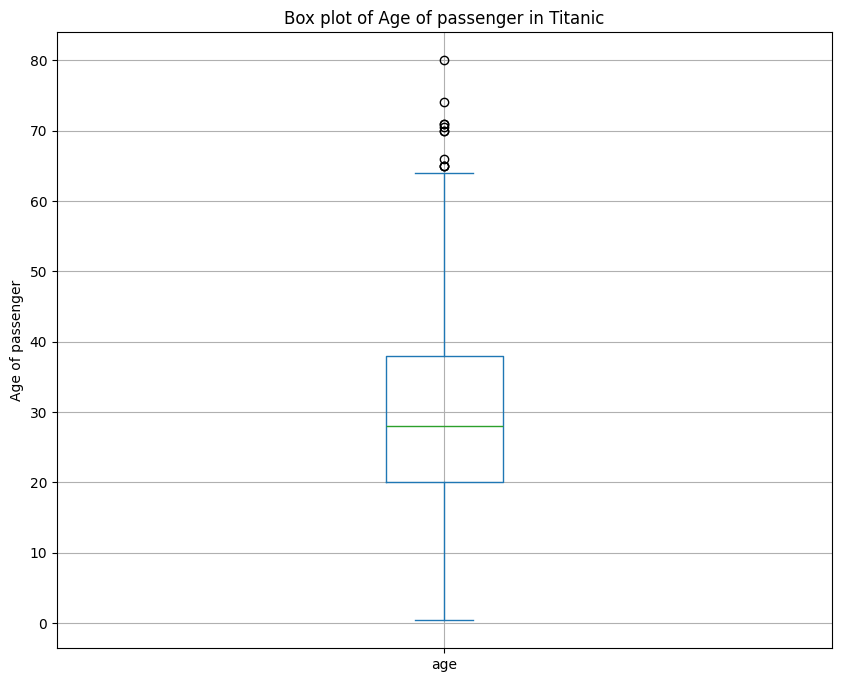

In [42]:
df.age.plot(
    kind = "box",
    figsize = (10,8),
    title = "Box plot of Age of passenger in Titanic",
    ylabel = "Age of passenger",
    grid = True
)

In [38]:
Q1 = df.age.quantile(q = 0.25)
Q3 = df.age.quantile(q = 0.75)

IQR  = Q3 - Q1

In [43]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [44]:
print("Upper limit:\t",upper_limit)
print("Lower limit:\t",lower_limit)

Upper limit:	 64.8125
Lower limit:	 -6.6875


In [62]:
print(df_change.shape)

(886, 11)


In [65]:
new_df = df[(df["age"] >= lower_limit) & (df["age"] <= upper_limit) ]
print(new_df.shape)
print("Outlier free data:\n",new_df.sample(5))

(703, 15)
Outlier free data:
      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
232         0       2    male  59.0      0      0  13.5000        S  Second   
799         0       3  female  30.0      1      1  24.1500        S   Third   
218         1       1  female  32.0      0      0  76.2917        C   First   
439         0       2    male  31.0      0      0  10.5000        S  Second   
357         0       2  female  38.0      0      0  13.0000        S  Second   

       who  adult_male deck  embark_town alive  alone  
232    man        True  NaN  Southampton    no   True  
799  woman       False  NaN  Southampton    no  False  
218  woman       False    D    Cherbourg   yes   True  
439    man        True  NaN  Southampton    no   True  
357  woman       False  NaN  Southampton    no   True  


<Axes: >

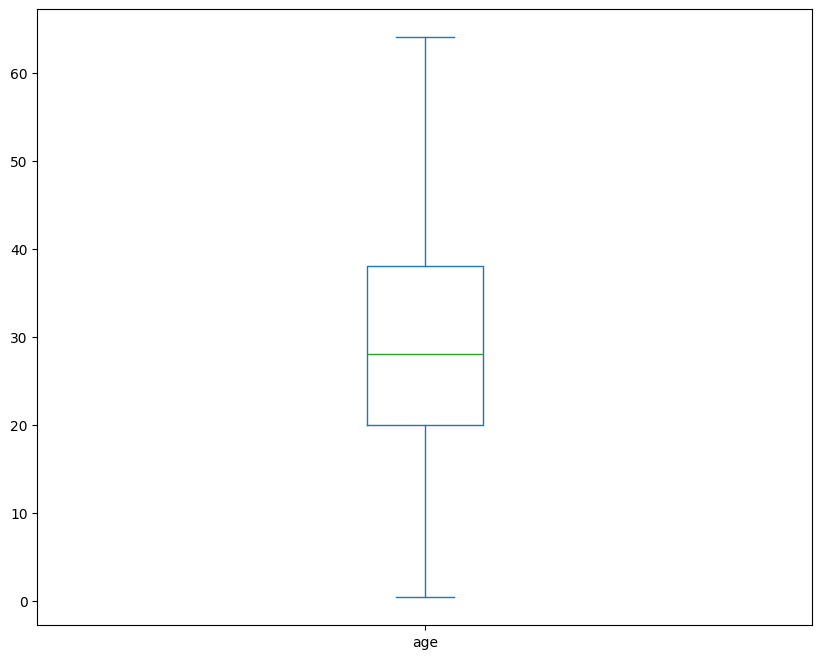

In [66]:
new_df.age.plot(kind = "box",figsize = (10,8))

In [68]:
new_df = df[(df["age"] < lower_limit) | (df["age"] > upper_limit) ]
print(new_df.shape)
print("Outlier data:\n",new_df)

(11, 15)
Outlier data:
      survived  pclass   sex   age  sibsp  parch     fare embarked   class  \
33          0       2  male  66.0      0      0  10.5000        S  Second   
54          0       1  male  65.0      0      1  61.9792        C   First   
96          0       1  male  71.0      0      0  34.6542        C   First   
116         0       3  male  70.5      0      0   7.7500        Q   Third   
280         0       3  male  65.0      0      0   7.7500        Q   Third   
456         0       1  male  65.0      0      0  26.5500        S   First   
493         0       1  male  71.0      0      0  49.5042        C   First   
630         1       1  male  80.0      0      0  30.0000        S   First   
672         0       2  male  70.0      0      0  10.5000        S  Second   
745         0       1  male  70.0      1      1  71.0000        S   First   
851         0       3  male  74.0      0      0   7.7750        S   Third   

     who  adult_male deck  embark_town alive  alone

- **Using Z-score for handling outliers**

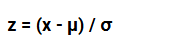

In [70]:
sample = [150,155,160,165,170,175,180]

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof = 1)

z_score = (sample - sample_mean) / sample_std
z_score

array([-1.38873015, -0.9258201 , -0.46291005,  0.        ,  0.46291005,
        0.9258201 ,  1.38873015])

In [72]:
z_score = abs(df.age - df.age.mean())/df.age.std()
z_score

,age
0,0.530005
1,0.571430
2,0.254646
3,0.364911
4,0.364911
...,...
886,0.185807
887,0.736524
888,NaN
889,0.254646


In [74]:
df["z_score"] = z_score
df[z_score > 2.5]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,z_score
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True,2.843141
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True,2.808721
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True,2.843141
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True,3.462699
672,0,2,male,70.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True,2.774301
745,0,1,male,70.0,1,1,71.0000,S,First,man,True,B,Southampton,no,False,2.774301
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True,3.049660


**zscore of fare colummn**

In [75]:
z_score  = abs(df.fare - df.fare.mean())/ df.fare.std()
z_score

,fare
0,0.502163
1,0.786404
2,0.488580
3,0.420494
4,0.486064
...,...
886,0.386454
887,0.044356
888,0.176164
889,0.044356


In [76]:
df[z_score > 2]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,z_score
27,0,1,male,19.00,3,2,263.0000,S,First,man,True,C,Southampton,no,False,0.736524
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False,NaN
88,1,1,female,23.00,3,2,263.0000,S,First,woman,False,C,Southampton,yes,False,0.461165
118,0,1,male,24.00,0,1,247.5208,C,First,man,True,B,Cherbourg,no,False,0.392326
195,1,1,female,58.00,0,0,146.5208,C,First,woman,False,B,Cherbourg,yes,True,1.948225
258,1,1,female,35.00,0,0,512.3292,C,First,woman,False,NaN,Cherbourg,yes,True,0.364911
268,1,1,female,58.00,0,1,153.4625,S,First,woman,False,C,Southampton,yes,False,1.948225
269,1,1,female,35.00,0,0,135.6333,S,First,woman,False,C,Southampton,yes,True,0.364911
297,0,1,female,2.00,1,2,151.5500,S,First,child,False,C,Southampton,no,False,1.906799
299,1,1,female,50.00,0,1,247.5208,C,First,woman,False,B,Cherbourg,yes,False,1.397507
